In [1]:
import json

with open('TelecomX_Data.json', 'r') as f:
    data = json.load(f)

len(data)
data[0]

{'customerID': '0002-ORFBO',
 'Churn': 'No',
 'customer': {'gender': 'Female',
  'SeniorCitizen': 0,
  'Partner': 'Yes',
  'Dependents': 'Yes',
  'tenure': 9},
 'phone': {'PhoneService': 'Yes', 'MultipleLines': 'No'},
 'internet': {'InternetService': 'DSL',
  'OnlineSecurity': 'No',
  'OnlineBackup': 'Yes',
  'DeviceProtection': 'No',
  'TechSupport': 'Yes',
  'StreamingTV': 'Yes',
  'StreamingMovies': 'No'},
 'account': {'Contract': 'One year',
  'PaperlessBilling': 'Yes',
  'PaymentMethod': 'Mailed check',
  'Charges': {'Monthly': 65.6, 'Total': '593.3'}}}

In [2]:
import pandas as pd

df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [3]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [4]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [6]:
df['account.Charges.Total'] = pd.to_numeric(
    df['account.Charges.Total'],
    errors='coerce'
)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [8]:
df.groupby('account.Contract')['Churn'].value_counts(normalize=True)

account.Contract  Churn
Month-to-month    No       0.554307
                  Yes      0.413233
                           0.032459
One year          No       0.860434
                  Yes      0.109282
                           0.030283
Two year          No       0.944923
                           0.027539
                  Yes      0.027539
Name: proportion, dtype: float64

In [9]:
df.groupby('internet.TechSupport')['Churn'].value_counts(normalize=True)

internet.TechSupport  Churn
No                    No       0.565885
                      Yes      0.403685
                               0.030430
No internet service   No       0.893738
                      Yes      0.071474
                               0.034788
Yes                   No       0.824144
                      Yes      0.147338
                               0.028517
Name: proportion, dtype: float64

In [10]:
df.isna().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['customerID'].duplicated().sum()

np.int64(0)

In [13]:
df[df['customer.tenure'] < 0]

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total


In [14]:
df[df['account.Charges.Monthly'] < 0]

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total


In [15]:
df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [16]:
df['account.Contract'].unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [17]:
df['internet.InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [18]:
(df['Churn'] == '').sum()

np.int64(224)

In [21]:
import numpy as np

df['Churn'] = df['Churn'].replace('', np.nan)

In [22]:
df['Churn'].isna().sum()
df['Churn'].unique()

array(['No', 'Yes', nan], dtype=object)

In [23]:
df = df.dropna(subset=['Churn'])

In [24]:
df['Churn'].unique()
df['Churn'].isna().sum()

np.int64(0)

In [25]:
df['Cuentas_Diarias'] = df['account.Charges.Monthly'] / 30

In [26]:
df[['account.Charges.Monthly', 'Cuentas_Diarias']].head()

,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [27]:
df['Cuentas_Diarias'].describe()

,Cuentas_Diarias
count,7043.000000
mean,2.158723
std,1.003002
min,0.608333
25%,1.183333
50%,2.345000
75%,2.995000
max,3.958333


In [28]:
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,2.158723
std,0.368612,24.559481,30.090047,2266.771362,1.003002
min,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.500000,401.450000,1.183333
50%,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,0.000000,55.000000,89.850000,3794.737500,2.995000
max,1.000000,72.000000,118.750000,8684.800000,3.958333


In [29]:
df[
    ['customer.tenure',
     'account.Charges.Monthly',
     'account.Charges.Total',
     'Cuentas_Diarias']
].describe()

,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7032.000000,7043.000000
mean,32.371149,64.761692,2283.300441,2.158723
std,24.559481,30.090047,2266.771362,1.003002
min,0.000000,18.250000,18.800000,0.608333
25%,9.000000,35.500000,401.450000,1.183333
50%,29.000000,70.350000,1397.475000,2.345000
75%,55.000000,89.850000,3794.737500,2.995000
max,72.000000,118.750000,8684.800000,3.958333


In [30]:
df.groupby('Churn')[
    ['customer.tenure',
     'account.Charges.Monthly',
     'account.Charges.Total',
     'Cuentas_Diarias']
].describe()

customer.tenure                                                     \
                count       mean        std  min   25%   50%   75%   max   
Churn                                                                      
No             5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0   
Yes            1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

      account.Charges.Monthly             ... account.Charges.Total           \
                        count       mean  ...                   75%      max   
Churn                                     ...                                  
No                     5174.0  61.265124  ...              4264.125  8672.45   
Yes                    1869.0  74.441332  ...              2331.300  8684.80   

      Cuentas_Diarias                                                  \
                count      mean       std       min       25%     50%   
Churn                                                                   
No             5174.0  2.042171  1.036422  0.608333  0.836667  2.1475   
Yes            1869.0  2.481378  0.822202  0.628333  1.871667  2.6550   

                           
            75%       max  
Churn                      
No     2.946667  3.958333  
Yes    3.140000  3.945000  

[2 rows x 32 columns]

In [31]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [32]:
df['account.Contract'].value_counts(normalize=True)

,proportion
account.Contract,
Month-to-month,0.550192
Two year,0.240664
One year,0.209144


In [33]:
import pandas as pd

pd.options.display.float_format = '{:.2f}'.format

In [34]:
pd.options.display.float_format = '{:.2f}'.format
df.describe().round(2)

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7043.00,7043.00,7043.00,7032.00,7043.00
mean,0.16,32.37,64.76,2283.30,2.16
std,0.37,24.56,30.09,2266.77,1.00
min,0.00,0.00,18.25,18.80,0.61
25%,0.00,9.00,35.50,401.45,1.18
50%,0.00,29.00,70.35,1397.48,2.34
75%,0.00,55.00,89.85,3794.74,2.99
max,1.00,72.00,118.75,8684.80,3.96


In [35]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [36]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.46
Yes,26.54


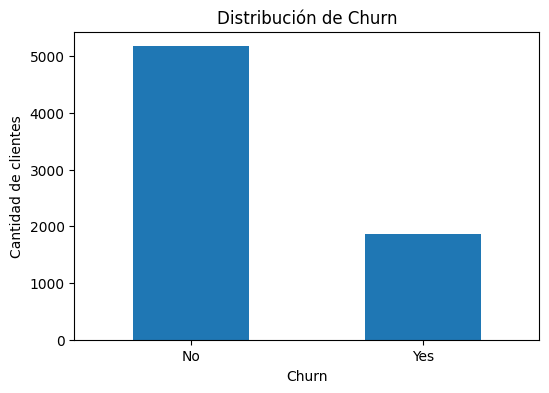

In [37]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,4))
churn_counts.plot(kind='bar')
plt.title('Distribución de Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.show()

In [38]:
pd.crosstab(df['account.Contract'], df['Churn'])

Churn,No,Yes
account.Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [39]:
pd.crosstab(
    df['account.Contract'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
account.Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [41]:
pd.crosstab(
    df['internet.InternetService'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
internet.InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


In [42]:
pd.crosstab(
    df['account.PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
account.PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


In [43]:
df.groupby('Churn')[
    ['customer.tenure',
     'account.Charges.Monthly',
     'account.Charges.Total',
     'Cuentas_Diarias']
].describe().round(2)

customer.tenure                                           \
                count  mean   std  min   25%   50%   75%   max   
Churn                                                            
No            5174.00 37.57 24.11 0.00 15.00 38.00 61.00 72.00   
Yes           1869.00 17.98 19.53 1.00  2.00 10.00 29.00 72.00   

      account.Charges.Monthly        ... account.Charges.Total          \
                        count  mean  ...                   75%     max   
Churn                                ...                                 
No                    5174.00 61.27  ...               4264.12 8672.45   
Yes                   1869.00 74.44  ...               2331.30 8684.80   

      Cuentas_Diarias                                     
                count mean  std  min  25%  50%  75%  max  
Churn                                                     
No            5174.00 2.04 1.04 0.61 0.84 2.15 2.95 3.96  
Yes           1869.00 2.48 0.82 0.63 1.87 2.66 3.14 3.94  

[2 rows x 32 columns]

<Figure size 600x400 with 0 Axes>

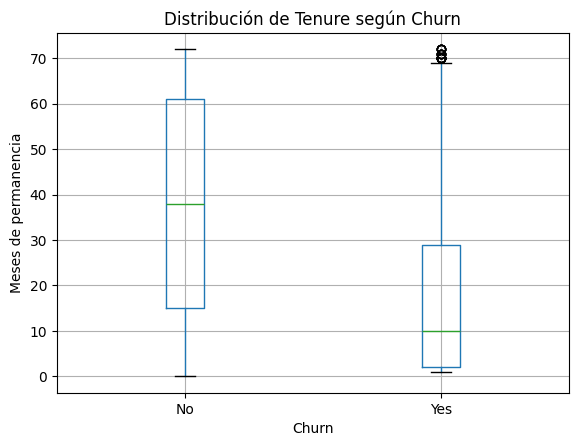

In [44]:
plt.figure(figsize=(6,4))
df.boxplot(
    column='customer.tenure',
    by='Churn'
)
plt.title('Distribución de Tenure según Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Meses de permanencia')
plt.show()

<Figure size 600x400 with 0 Axes>

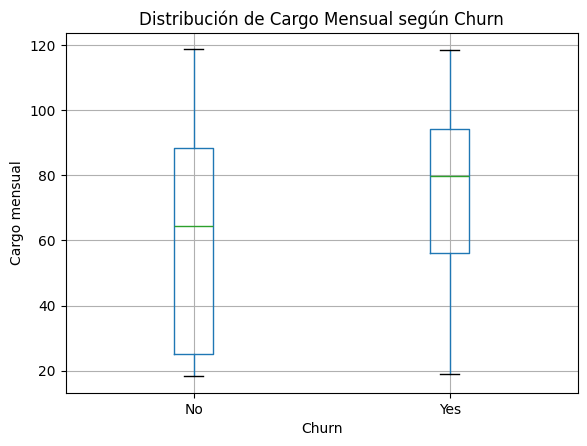

In [45]:
plt.figure(figsize=(6,4))
df.boxplot(
    column='account.Charges.Monthly',
    by='Churn'
)
plt.title('Distribución de Cargo Mensual según Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Cargo mensual')
plt.show()

<Figure size 600x400 with 0 Axes>

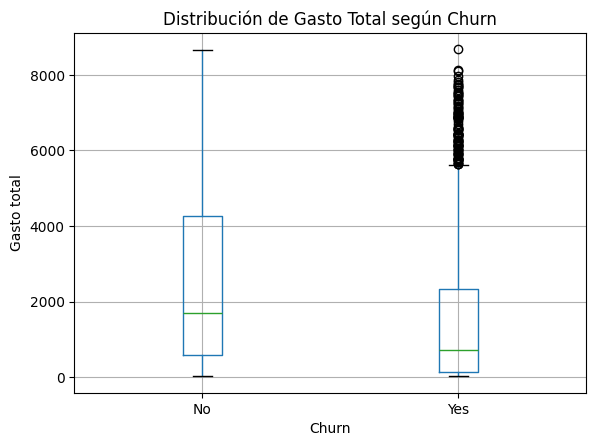

In [46]:
plt.figure(figsize=(6,4))
df.boxplot(
    column='account.Charges.Total',
    by='Churn'
)
plt.title('Distribución de Gasto Total según Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Gasto total')
plt.show()

Introducción

La evasión de clientes (Churn) representa uno de los principales desafíos para las empresas de telecomunicaciones, ya que impacta directamente en los ingresos y en la sostenibilidad del negocio. Comprender los factores que influyen en la cancelación de servicios permite diseñar estrategias de retención más efectivas y focalizadas.

El objetivo de este análisis es explorar y comprender el comportamiento de los clientes, identificando patrones asociados a la evasión mediante el uso de técnicas de análisis exploratorio de datos (EDA). Para ello, se analizan variables demográficas, contractuales, de servicio y de facturación, con el fin de extraer insights que ayuden a reducir la tasa de churn.

Limpieza y Tratamiento de Datos

Los datos fueron cargados desde un archivo en formato JSON y posteriormente transformados a un DataFrame de Pandas para facilitar su manipulación y análisis.

Durante el proceso de limpieza y preparación se realizaron las siguientes acciones:

Normalización de la estructura JSON anidada utilizando pd.json_normalize.

Verificación de tipos de datos y corrección de inconsistencias.

 Conversión de la variable account.Charges.Total de tipo object a float, corrigiendo problemas de formato.

Identificación y tratamiento de valores nulos, especialmente en la variable objetivo Churn.

Creación de la variable Cuentas_Diarias, calculada a partir del cargo mensual, para obtener una métrica de costo diario por cliente.

Ajuste del formato de visualización numérica para mejorar la claridad y presentación de los resultados.

Análisis Exploratorio de Datos

1.1 Distribución de la evasión (Churn)

El análisis inicial de la variable objetivo mostró la siguiente distribución:

73.46% de los clientes no presentan evasión.

26.54% de los clientes cancelaron el servicio.

Esto indica un desbalance moderado, con una proporción relevante de clientes que abandonan, justificando un análisis detallado de los factores asociados al churn.

1.2 Evasión por variables categóricas

Se analizaron variables categóricas clave para identificar perfiles de mayor riesgo:

Tipo de contrato:
Los clientes con contrato Month-to-month presentan la tasa de evasión más alta (42.71%), mientras que los contratos de uno y dos años muestran tasas significativamente menores, especialmente los contratos de dos años (2.83%).

Tipo de servicio de internet:
Los clientes con Fiber optic presentan una tasa de churn elevada (41.89%), en comparación con clientes con DSL o sin servicio de internet.

Método de pago:
El método Electronic check presenta la mayor tasa de evasión (45.29%), mientras que los métodos automáticos están asociados a una mayor retención.

Estos resultados sugieren que el compromiso contractual y la estabilidad en los pagos influyen fuertemente en la permanencia de los clientes.

1.3 Evasión por variables numéricas

El análisis de variables numéricas reveló diferencias claras entre clientes que evaden y los que permanecen:

Tenure (tiempo de permanencia):
Los clientes con churn presentan una mediana de solo 10 meses, frente a 38 meses en clientes que permanecen, indicando que la evasión ocurre principalmente en etapas tempranas.

Cargo mensual:
Los clientes que cancelan el servicio tienen cargos mensuales más altos en promedio, lo que sugiere una posible sensibilidad al precio.

Gasto total:
Los clientes que permanecen acumulan un mayor gasto total, coherente con su mayor tiempo de permanencia.

Cuentas Diarias:
El costo diario promedio es mayor en clientes con churn, reforzando la relación entre costos elevados y evasión.

Conclusiones e Insights

A partir del análisis realizado, se destacan los siguientes hallazgos:

La evasión está fuertemente asociada a menor tiempo de permanencia.

Los cargos elevados (mensuales y diarios) están relacionados con una mayor probabilidad de churn.

El tipo de contrato es uno de los factores más determinantes en la retención.

Los clientes con pagos no automáticos presentan mayor tendencia a cancelar el servicio.

Existen perfiles claros de alto riesgo que pueden ser identificados tempranamente.


Recomendaciones

Con base en los resultados obtenidos, se proponen las siguientes acciones estratégicas:

Incentivar la migración desde contratos Month-to-month hacia contratos de mayor duración mediante beneficios o descuentos.

Revisar la estructura de precios y calidad del servicio para clientes con Fiber optic, con el fin de reducir la evasión asociada.

Promover el uso de métodos de pago automáticos, ofreciendo incentivos por su adopción.

Implementar estrategias de retención temprana enfocadas en clientes con bajo tenure.

Utilizar estas variables como base para el desarrollo de modelos predictivos de churn, que permitan anticipar cancelaciones y actuar de forma proactiva.

El análisis exploratorio realizado permite comprender de forma clara los factores que influyen en la evasión de clientes. Estos resultados constituyen un insumo clave para la toma de decisiones estratégicas orientadas a mejorar la retención y optimizar la relación con los clientes.